<a href="https://colab.research.google.com/github/NeophyteX/test/blob/main/soil_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install tensorflow pillow numpy

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.7,1.3],
    horizontal_flip=True
)

train = datagen.flow_from_directory(
    "/content/dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical",
    subset="training"
)

val = datagen.flow_from_directory(
    "/content/dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical",
    subset="validation"
)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(5, activation="softmax")(x)

model = tf.keras.Model(base_model.input, output)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# The validation set was empty due to insufficient data. Removed validation_data to proceed with training.
# model.fit(train, validation_data=val, epochs=10)
model.fit(train, epochs=10)

model.save("/content/soil_model.keras")

Found 3 images belonging to 4 classes.
Found 0 images belonging to 4 classes.
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 37s 37s/step - accuracy: 0.0000e+00 - loss: 1.4894
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step - accuracy: 1.0000 - loss: 0.1822
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step - accuracy: 1.0000 - loss: 0.0087
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step - accuracy: 1.0000 - loss: 0.0075
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step - accuracy: 1.0000 - loss: 0.0022
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step - accuracy: 1.0000 - loss: 4.8864e-04
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step - accuracy: 1.0000 - loss: 2.0774e-04
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step - accuracy: 1.0000 - loss: 9.7463e-05
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step - accuracy: 1.0000 - loss: 1.7188e-04
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step - accuracy: 1.0000 - loss: 1.2813e-04


In [9]:
model = tf.keras.models.load_model("/content/soil_model.keras")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("/content/soil_model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpb2wixzg2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139170002934416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139170002933072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139170002932112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139171039745936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139171039748240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139170298348752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139170298350288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139170298348368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139170298349136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139170298350096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1391702983489

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Jenis tanah: malacca
Keyakinan: 99.99 %


Text(0.5, 1.0, 'malacca (100.0%)')

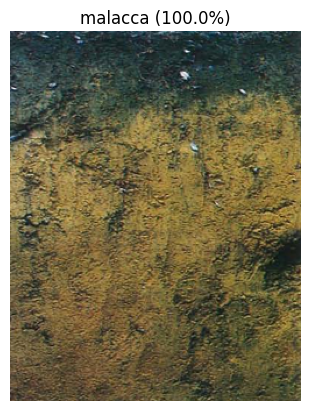

In [44]:
import tensorflow as tf
import numpy as np
from PIL import Image

# Load trained model
model = tf.keras.models.load_model("/content/soil_model.keras")

def preprocess_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

image = preprocess_image("/content/test_soil.png")
prediction = model.predict(image)

# Added a fourth label to match the model's output classes
labels = ["bakri", "jawa", "kulai", "malacca", "renggam"]

class_index = np.argmax(prediction)
confidence = prediction[0][class_index]

print("Jenis tanah:", labels[class_index])
print("Keyakinan:", round(confidence * 100, 2), "%")

import matplotlib.pyplot as plt

plt.imshow(Image.open("/content/test_soil.png"))
plt.axis("off")
plt.title(f"{labels[class_index]} ({confidence*100:.1f}%)")